- Task: Develop a machine learning model that predicts a target feature (of your identification) within the selected dataset.
- Chosen Dataset: Heart Failure Clinical Records (Regression, Classification, Clustering)

- Referenced kaggle Resource: https://www.kaggle.com/datasets/whenamancodes/heart-failure-clinical-records
- Info from kaggle resource: Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worlwide.
Heart failure is a common event caused by CVDs and this dataset contains 12 features that can be used to predict mortality by heart failure.

Most cardiovascular diseases can be prevented by addressing behavioural risk factors such as tobacco use, unhealthy diet and obesity, physical inactivity and harmful use of alcohol using population-wide strategies.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.
Attribute Information:

Thirteen (13) clinical features:

    age: age of the patient (years)
    anaemia: decrease of red blood cells or hemoglobin (boolean)
    high blood pressure: if the patient has hypertension (boolean)
    creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
    diabetes: if the patient has diabetes (boolean)
    ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
    platelets: platelets in the blood (kiloplatelets/mL)
    sex: woman or man (binary)
    serum creatinine: level of serum creatinine in the blood (mg/dL)
    serum sodium: level of serum sodium in the blood (mEq/L)
    smoking: if the patient smokes or not (boolean)
    time: follow-up period (days)
    [target] death event: if the patient deceased during the follow-up period (boolean)

- Referenced relevant research: https://link.springer.com/article/10.1186/s12911-020-1023-5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

In [2]:
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
data

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [5]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [6]:
for i in data:
    print(i,len(data[i].unique().tolist()))

age 47
anaemia 2
creatinine_phosphokinase 208
diabetes 2
ejection_fraction 17
high_blood_pressure 2
platelets 176
serum_creatinine 40
serum_sodium 27
sex 2
smoking 2
time 148
DEATH_EVENT 2


In [7]:
categoricals = ["anaemia","diabetes","ejection_fraction","high_blood_pressure","diabetes","sex","smoking", "DEATH_EVENT"]
for i in data:
    if i in categoricals:
        print(i,len(data[i].unique().tolist()), data[i].unique())

anaemia 2 [0 1]
diabetes 2 [0 1]
ejection_fraction 17 [20 38 40 15 60 65 35 25 30 50 14 55 45 62 80 17 70]
high_blood_pressure 2 [1 0]
sex 2 [1 0]
smoking 2 [0 1]
DEATH_EVENT 2 [1 0]


In [8]:
for i in data:
    if i in categoricals:
        print(data[i].value_counts(),"\n")

anaemia
0    170
1    129
Name: count, dtype: int64 

diabetes
0    174
1    125
Name: count, dtype: int64 

ejection_fraction
35    49
38    40
40    37
25    36
30    34
60    31
50    21
45    20
20    18
55     3
15     2
62     2
17     2
65     1
14     1
80     1
70     1
Name: count, dtype: int64 

high_blood_pressure
0    194
1    105
Name: count, dtype: int64 

sex
1    194
0    105
Name: count, dtype: int64 

smoking
0    203
1     96
Name: count, dtype: int64 

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64 



Text(0.5, 1.0, 'Correlation Heatmap of the Heart Failure Records Dataset')

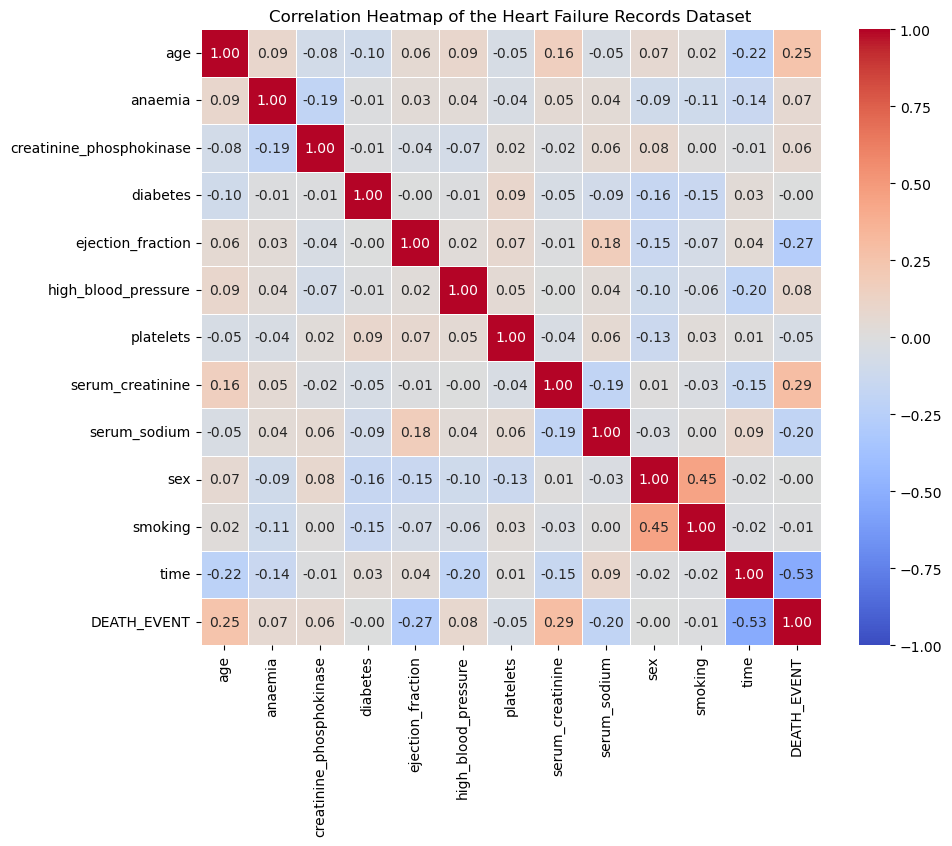

In [9]:
# Compute correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Set up figure size
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, # Display correlation values
    cmap="coolwarm", # Color palette
    fmt=".2f", # Format annotations
    linewidths=0.5,
    vmin=-1, 
    vmax=1,
)

# Add title
plt.title("Correlation Heatmap of the Heart Failure Records Dataset")

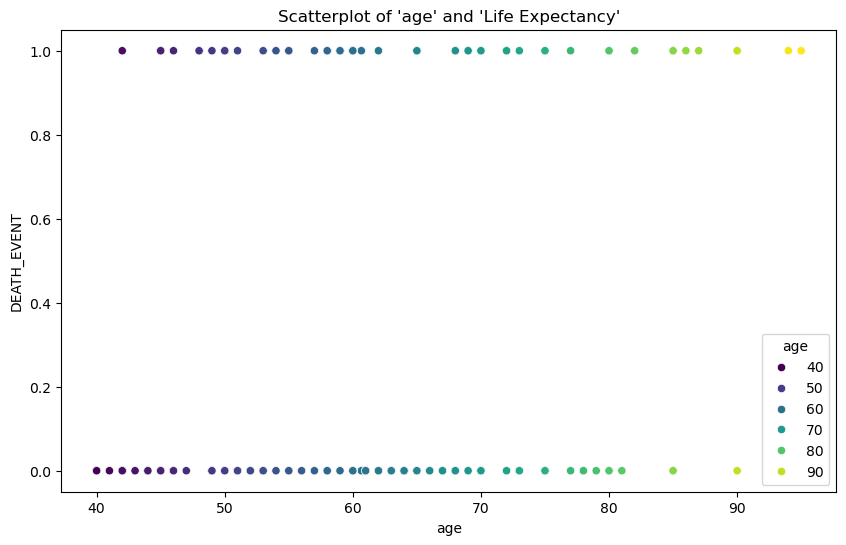

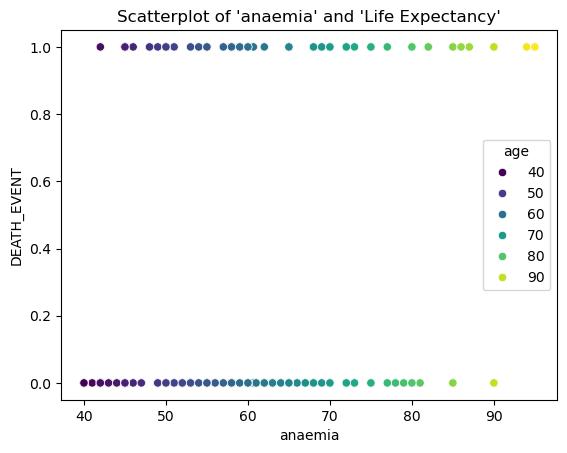

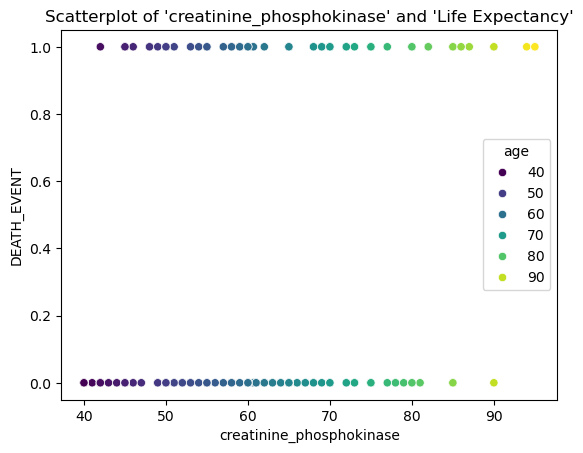

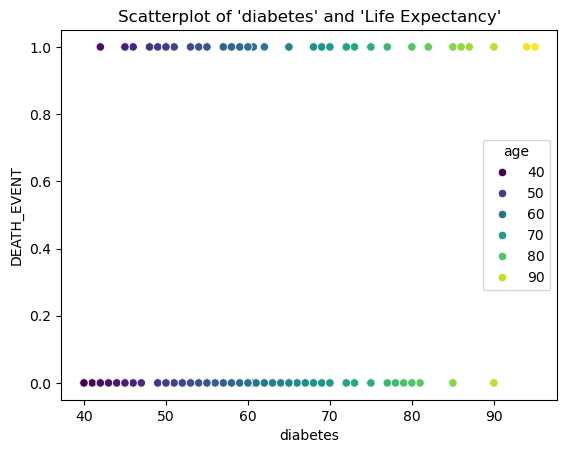

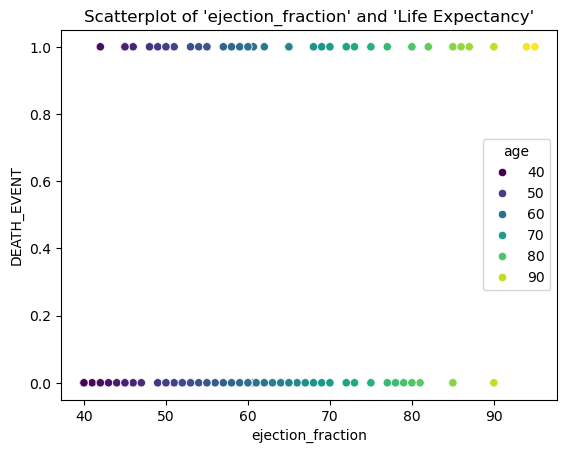

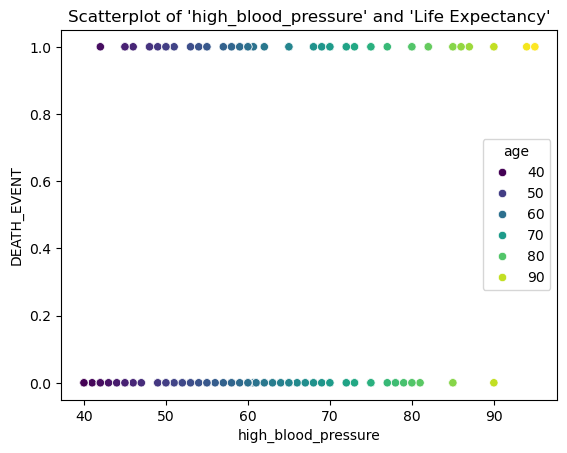

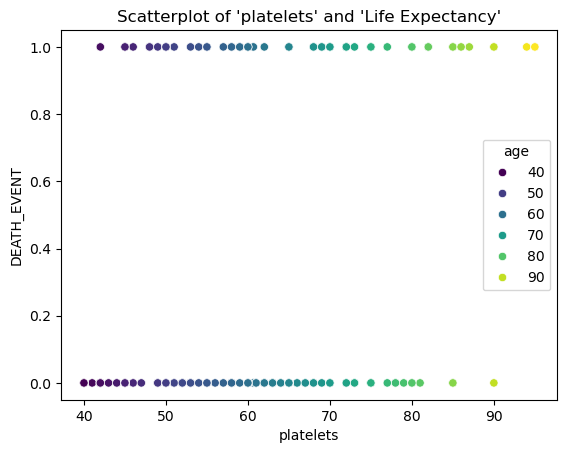

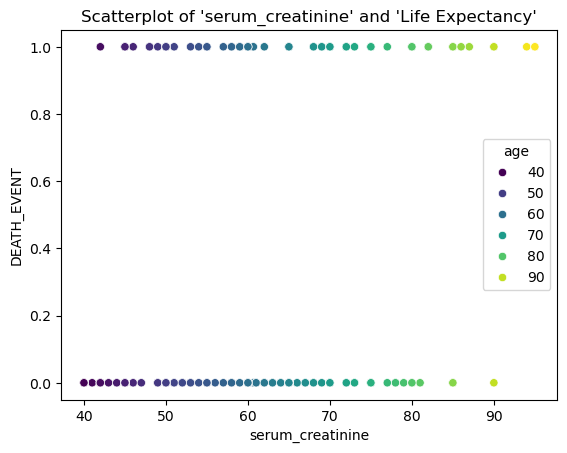

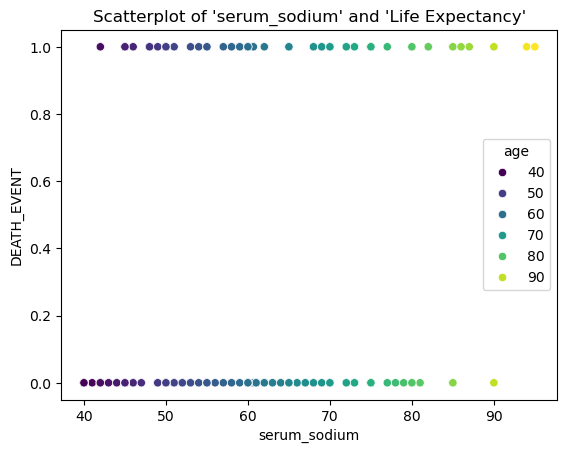

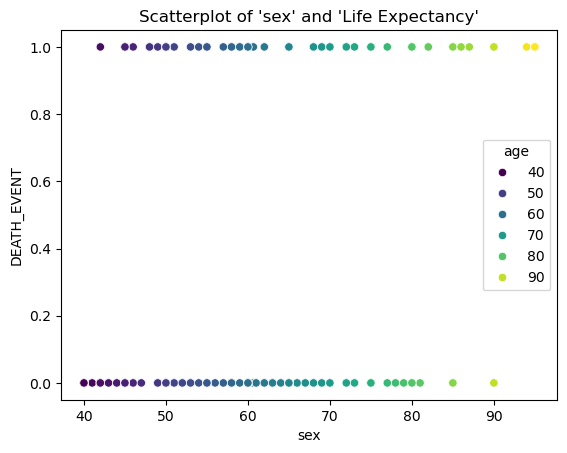

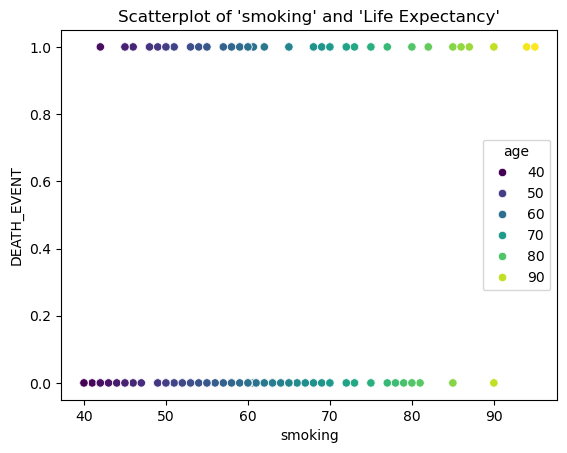

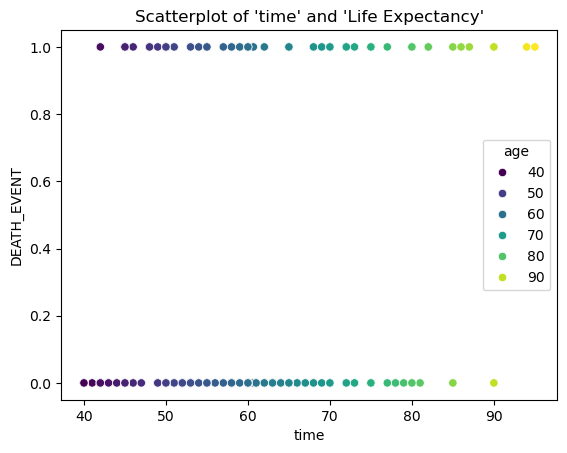

In [10]:
plt.figure(figsize=(10, 6))
for i in data:
    if i != 'DEATH_EVENT':
        sns.scatterplot(x='age', y='DEATH_EVENT', data=data, hue='age', palette='viridis')
        plt.title(f"Scatterplot of '{i}' and 'Life Expectancy'")
        plt.xlabel(i)
        plt.ylabel('DEATH_EVENT')
        plt.show()

In [11]:
# Split data into train,and test
X = data.drop('DEATH_EVENT', axis=1)
y = data['DEATH_EVENT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

In [12]:
logRmodel = LogisticRegression()
logRmodel.fit(X_train, y_train)

# Predict
y_pred = logRmodel.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Accurace
accuracy = accuracy_score(y_test, y_pred)

# F1 Score (macro for multiclass)
f1 = f1_score(y_test, y_pred)

# AUC
y_proba = logRmodel.predict_proba(X_test)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nLogistric Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Logistric Regression F1 Score (macro): {f1:.4f}")
print(f"Logistric Regression AUC (macro OVR): {auc:.4f}")

Confusion Matrix:
 [[33  2]
 [10 15]]

Logistric Regression Accuracy: 80.00%
Logistric Regression F1 Score (macro): 0.7143
Logistric Regression AUC (macro OVR): 0.8343


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn5model = KNeighborsClassifier(n_neighbors=5)
knn5model.fit(X_train_scaled, y_train)

# Predict
y_pred = knn5model.predict(X_test_scaled)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# AUC
y_proba = knn5model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nKNN (5 Neighbours) Accuracy: {accuracy * 100:.2f}%")
print(f"KNN (5 Neighbours) F1 Score (macro): {f1:.4f}")
print(f"KNN (5 Neighbours) AUC (macro OVR): {auc:.4f}")

Confusion Matrix:
 [[34  1]
 [18  7]]

KNN (5 Neighbours) Accuracy: 68.33%
KNN (5 Neighbours) F1 Score (macro): 0.4242
KNN (5 Neighbours) AUC (macro OVR): 0.7446


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn3model = KNeighborsClassifier(n_neighbors=3)
knn3model.fit(X_train_scaled, y_train)

# Predict
y_pred = knn3model.predict(X_test_scaled)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# AUC
y_proba = knn3model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nKNN (3 Neighbours) Accuracy: {accuracy * 100:.2f}%")
print(f"KNN (3 Neighbours) F1 Score (macro): {f1:.4f}")
print(f"KNN (3 Neighbours) AUC (macro OVR): {auc:.4f}")

Confusion Matrix:
 [[34  1]
 [15 10]]

KNN (3 Neighbours) Accuracy: 73.33%
KNN (3 Neighbours) F1 Score (macro): 0.5556
KNN (3 Neighbours) AUC (macro OVR): 0.7189


In [15]:
rsvcmodel = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# Train
rsvcmodel.fit(X_train_scaled, y_train)


# Predictions
y_pred = rsvcmodel.predict(X_test_scaled)
y_proba = rsvcmodel.predict_proba(X_test_scaled)[:, 1]   # probability of class 1

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nRBF SVC Accuracy: {accuracy * 100:.2f}%")
print(f"RBF SVC F1 Score: {f1:.4f}")
print(f"RBF SVC AUC: {auc:.4f}")

Confusion Matrix:
 [[33  2]
 [13 12]]

RBF SVC Accuracy: 75.00%
RBF SVC F1 Score: 0.6154
RBF SVC AUC: 0.8160


In [16]:
lsvcmodel = SVC(kernel='linear', probability=True, random_state=42)

# Train
lsvcmodel.fit(X_train_scaled, y_train)

# Predictions
y_pred = lsvcmodel.predict(X_test_scaled)
y_proba =lsvcmodel.predict_proba(X_test_scaled)[:, 1]   # probability of class 1

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nLinear SVC Accuracy Accuracy: {accuracy * 100:.2f}%")
print(f"Linear SVC Accuracy F1 Score: {f1:.4f}")
print(f"Linear SVC Accuracy AUC: {auc:.4f}\n\n")

Confusion Matrix:
 [[33  2]
 [10 15]]

Linear SVC Accuracy Accuracy: 80.00%
Linear SVC Accuracy F1 Score: 0.7143
Linear SVC Accuracy AUC: 0.8309




#### BEST MODELS: Logistic Regression and Linear SVM


Breakdown:
- Logistic Regression and Linear SVC: best balanced performance — highest accuracy, highest F1, best AUC. These are my safest choices for a strong overall model.

- RBF SVC: decent AUC and a middle-ground F1; lower recall (0.48) than above.

- KNN (both 5 neighbours and 3 neighbours): Comparatively lower F1 Scores. That means they rarely raise false alarms or they miss many true positives.


Accuracy + F1 Ranking:  Logistic Regression > Linear SVM > RBF SVM > KNN 3 > KNN 5

AUC ranking: Logistic Regression > Linear SVM > RBF SVM > KNN 5 > KNN 3. AUC differences between Logistic Regression and Linear SVM are very small (0.8343 vs 0.8309)

In [17]:
# Split data into train,and test
X = data.drop('DEATH_EVENT', axis=1)
y = data['DEATH_EVENT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
logRmodel = LogisticRegression()
logRmodel.fit(X_train, y_train)

# Predict
y_pred = logRmodel.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Accurace
accuracy = accuracy_score(y_test, y_pred)

# F1 Score (macro for multiclass)
f1 = f1_score(y_test, y_pred)

# AUC
y_proba = logRmodel.predict_proba(X_test)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nLogistric Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Logistric Regression F1 Score (macro): {f1:.4f}")
print(f"Logistric Regression AUC (macro OVR): {auc:.4f}")

Confusion Matrix:
 [[39  2]
 [ 8 11]]

Logistric Regression Accuracy: 83.33%
Logistric Regression F1 Score (macro): 0.6875
Logistric Regression AUC (macro OVR): 0.8562


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn5model = KNeighborsClassifier(n_neighbors=5)
knn5model.fit(X_train_scaled, y_train)

# Predict
y_pred = knn5model.predict(X_test_scaled)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# AUC
y_proba = knn5model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nKNN (5 Neighbours) Accuracy: {accuracy * 100:.2f}%")
print(f"KNN (5 Neighbours) F1 Score (macro): {f1:.4f}")
print(f"KNN (5 Neighbours) AUC (macro OVR): {auc:.4f}")

Confusion Matrix:
 [[38  3]
 [15  4]]

KNN (5 Neighbours) Accuracy: 70.00%
KNN (5 Neighbours) F1 Score (macro): 0.3077
KNN (5 Neighbours) AUC (macro OVR): 0.8004


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn3model = KNeighborsClassifier(n_neighbors=3)
knn3model.fit(X_train_scaled, y_train)

# Predict
y_pred = knn3model.predict(X_test_scaled)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# AUC
y_proba = knn3model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nKNN (3 Neighbours) Accuracy: {accuracy * 100:.2f}%")
print(f"KNN (3 Neighbours) F1 Score (macro): {f1:.4f}")
print(f"KNN (3 Neighbours) AUC (macro OVR): {auc:.4f}")

Confusion Matrix:
 [[39  2]
 [15  4]]

KNN (3 Neighbours) Accuracy: 71.67%
KNN (3 Neighbours) F1 Score (macro): 0.3200
KNN (3 Neighbours) AUC (macro OVR): 0.7291


In [21]:
rsvcmodel = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# Train
rsvcmodel.fit(X_train_scaled, y_train)


# Predictions
y_pred = rsvcmodel.predict(X_test_scaled)
y_proba = rsvcmodel.predict_proba(X_test_scaled)[:, 1]   # probability of class 1

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nRBF SVC Accuracy: {accuracy * 100:.2f}%")
print(f"RBF SVC F1 Score: {f1:.4f}")
print(f"RBF SVC AUC: {auc:.4f}")

Confusion Matrix:
 [[38  3]
 [11  8]]

RBF SVC Accuracy: 76.67%
RBF SVC F1 Score: 0.5333
RBF SVC AUC: 0.8447


In [22]:
lsvcmodel = SVC(kernel='linear', probability=True, random_state=42)

# Train
lsvcmodel.fit(X_train_scaled, y_train)

# Predictions
y_pred = lsvcmodel.predict(X_test_scaled)
y_proba =lsvcmodel.predict_proba(X_test_scaled)[:, 1]   # probability of class 1

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nLinear SVC Accuracy Accuracy: {accuracy * 100:.2f}%")
print(f"Linear SVC Accuracy F1 Score: {f1:.4f}")
print(f"Linear SVC Accuracy AUC: {auc:.4f}\n\n")

Confusion Matrix:
 [[39  2]
 [11  8]]

Linear SVC Accuracy Accuracy: 78.33%
Linear SVC Accuracy F1 Score: 0.5517
Linear SVC Accuracy AUC: 0.8562




Stratifying the train_test_split improved all the models' performances but reduced Linear SVC's accuracy to 78.33%, making Logistic Regression my overall best model

### PERMUTATION IMPORTANCE FOR FEATURE IMPORTANCE/MODEL 'OPTIMZATION' (ChatGPT - assisted)

Permutation importance (LogisticRegression) — top features:
                 feature  importance_mean  importance_std
                    time         0.254643        0.079552
       ejection_fraction         0.048823        0.026600
                     age         0.046727        0.015364
               platelets         0.002054        0.004027
            serum_sodium         0.000599        0.003488
        serum_creatinine         0.000300        0.000543
                 anaemia         0.000000        0.000000
                diabetes         0.000000        0.000000
     high_blood_pressure         0.000000        0.000000
                     sex         0.000000        0.000000
                 smoking         0.000000        0.000000
creatinine_phosphokinase        -0.002225        0.007154


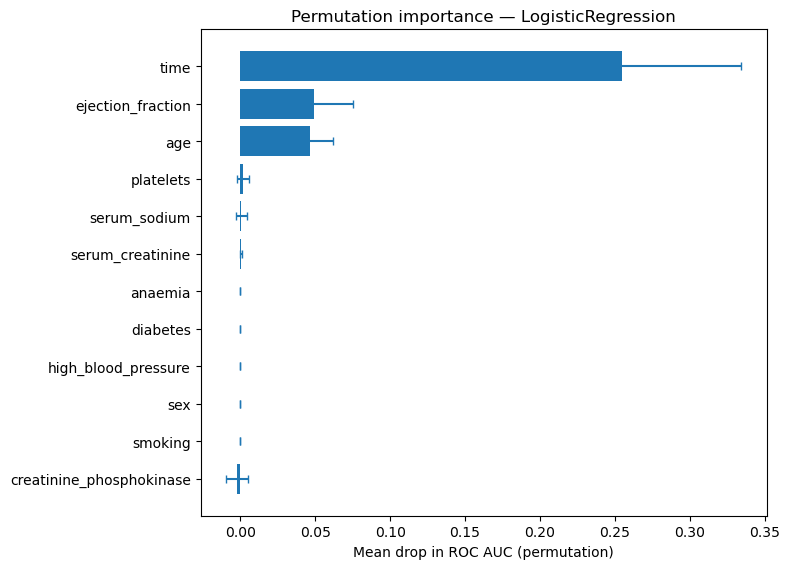

In [23]:
# --- Prepare X_test_for_model and feature names ---
# If X_test is a DataFrame, we'll use its columns for labels; otherwise supply a list `feature_names`.
if hasattr(X_test, "columns"):
    X_test_for_model = X_test
    feature_names = X_test.columns.tolist()
else:
    X_test_for_model = X_test  # numpy array
    # If you don't have names, create generic ones
    feature_names = [f"feat_{i}" for i in range(X_test.shape[1])]

# --- Permutation importance ---
perm_res = permutation_importance(
    logRmodel,                    # your trained LogisticRegression
    X_test_for_model,
    y_test,
    scoring="roc_auc",        # change if you prefer 'accuracy' or 'f1'
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

# --- Build DataFrame of importances (mean ± std) ---
perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_res.importances_mean,
    "importance_std": perm_res.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance (LogisticRegression) — top features:")
print(perm_df.head(20).to_string(index=False))

# --- Plot top 15 ---
topk = min(15, len(feature_names))
top = perm_df.head(topk).iloc[::-1]  # reverse for horizontal bar order
plt.figure(figsize=(8, 0.4*topk + 1))
plt.barh(top["feature"], top["importance_mean"])
plt.errorbar(top["importance_mean"], top["feature"], xerr=top["importance_std"], fmt='none', capsize=3)
plt.xlabel("Mean drop in ROC AUC (permutation)")
plt.title("Permutation importance — LogisticRegression")
plt.tight_layout()
plt.show()

Permutation importance (Linear SVC) — top features:
                 feature  importance_mean  importance_std
                    time         0.254857        0.074537
       ejection_fraction         0.038425        0.020855
        serum_creatinine         0.029696        0.022010
                     age         0.027642        0.009273
            serum_sodium         0.020368        0.007877
                     sex         0.009842        0.007150
     high_blood_pressure         0.004664        0.009074
creatinine_phosphokinase         0.001155        0.008453
               platelets         0.001070        0.001409
                 anaemia        -0.002139        0.010546
                 smoking        -0.004964        0.005880
                diabetes        -0.009285        0.008130


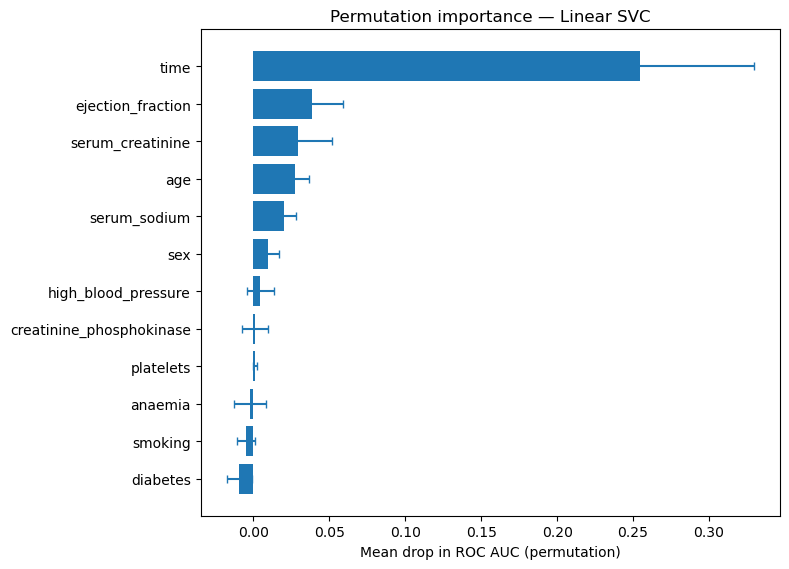

In [24]:
# --- Prepare X_test_for_model and feature names ---
# Prefer feature names from (in order): X_test_scaled (if DataFrame) -> X_test (DataFrame) -> X (DataFrame).
# Otherwise fall back to generic names.
if hasattr(X_test_scaled, "columns"):
    X_test_for_model = X_test_scaled
    feature_names = X_test_scaled.columns.tolist()
elif 'X_test' in globals() and hasattr(X_test, "columns"):
    X_test_for_model = X_test_scaled  # still use scaled array for the model
    feature_names = X_test.columns.tolist()
elif 'X' in globals() and hasattr(X, "columns"):
    X_test_for_model = X_test_scaled
    feature_names = X.columns.tolist()
else:
    X_test_for_model = X_test_scaled
    feature_names = [f"feat_{i}" for i in range(X_test_scaled.shape[1])]

# --- Permutation importance (Linear SVC) ---
perm_res_svc = permutation_importance(
    lsvcmodel,                    # your trained linear SVC
    X_test_for_model,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_df_svc = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_res_svc.importances_mean,
    "importance_std": perm_res_svc.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance (Linear SVC) — top features:")
print(perm_df_svc.head(20).to_string(index=False))

# --- Plot top 15 (correctly align error bars) ---
topk = min(15, len(feature_names))
top = perm_df_svc.head(topk).iloc[::-1]   # reverse for horizontal order

y_pos = list(range(len(top)))  # numeric positions for plotting
plt.figure(figsize=(8, 0.4*topk + 1))
plt.barh(y_pos, top["importance_mean"], align='center')
plt.errorbar(top["importance_mean"], y_pos, xerr=top["importance_std"], fmt='none', capsize=3)
plt.yticks(y_pos, top["feature"])
plt.xlabel("Mean drop in ROC AUC (permutation)")
plt.title("Permutation importance — Linear SVC")
plt.tight_layout()
plt.show()

I am motivated to perform this feature importance method because while trying to learn more about my dataset I came across a research work using the same dataset titled "Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone". (link in the description at the start of the file)

The two models share time, age and ejection fraction in their top 5 most important features. I am going to retrain the models and add serum creatinine to that list ad retrain the models (result: Log. Reg. performance remainede same, but Linear SVC saw a small booost)

In [25]:
X_new = data[['time', 'age', 'ejection_fraction', 'serum_creatinine']]
y_new= data['DEATH_EVENT']
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

In [26]:
logRmodel = LogisticRegression()
logRmodel.fit(X_train, y_train)

# Predict
y_pred = logRmodel.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Accurace
accuracy = accuracy_score(y_test, y_pred)

# F1 Score (macro for multiclass)
f1 = f1_score(y_test, y_pred)

# AUC
y_proba = logRmodel.predict_proba(X_test)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nLogistric Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Logistric Regression F1 Score (macro): {f1:.4f}")
print(f"Logistric Regression AUC (macro OVR): {auc:.4f}")

Confusion Matrix:
 [[39  2]
 [ 8 11]]

Logistric Regression Accuracy: 83.33%
Logistric Regression F1 Score (macro): 0.6875
Logistric Regression AUC (macro OVR): 0.8614


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lsvcmodel = SVC(kernel='linear', probability=True, random_state=42)

# Train
lsvcmodel.fit(X_train_scaled, y_train)

# Predictions
y_pred = lsvcmodel.predict(X_test_scaled)
y_proba =lsvcmodel.predict_proba(X_test_scaled)[:, 1]   # probability of class 1

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')
auc = roc_auc_score(y_test, y_proba)

# Print results
print(f"\nLinear SVC Accuracy Accuracy: {accuracy * 100:.2f}%")
print(f"Linear SVC Accuracy F1 Score: {f1:.4f}")
print(f"Linear SVC Accuracy AUC: {auc:.4f}\n\n")

Confusion Matrix:
 [[38  3]
 [ 8 11]]

Linear SVC Accuracy Accuracy: 81.67%
Linear SVC Accuracy F1 Score: 0.6667
Linear SVC Accuracy AUC: 0.8639


